# Cloud Dynamics — Empirical Analysis
Virtualenv-based Jupyter analysis of completed experiments.

In [1]:
from pathlib import Path
import os, pandas as pd, matplotlib.pyplot as plt
RESULTS=Path(os.environ.get('RESULTS_DIR','../cloud-dynamics-experiments/results')).resolve()
OUTPUTS=Path('../outputs').resolve(); OUTPUTS.mkdir(parents=True,exist_ok=True)
print('Results:',RESULTS)


Results: /storage3/home/royyana/Project/cloud2023/kubernetes/research/cloud-dynamics-experiments/results


In [2]:
experiments=sorted(p for p in RESULTS.iterdir() if p.is_dir() and (p/'combined.csv').exists())
pd.DataFrame({'index':range(len(experiments)),'experiment':[p.name for p in experiments]})


,index,experiment
0,0,constant-20261006T022000Z-r4


In [3]:
EXPERIMENT_INDEX=0
EXPERIMENT=experiments[EXPERIMENT_INDEX]
df=pd.read_csv(EXPERIMENT/'combined.csv')
df.head()


,timestamp_epoch,elapsed_s,target_rps,sent,success,failed,achieved_rps,mean_latency_ms,p95_latency_ms,CPU_USAGE,CPU_THROTTLED,MEMORY_WORKING_SET,NETWORK_RX,NETWORK_TX,RESTARTS,READY_PODS,LINKERD_REQUEST_RATE,LINKERD_SUCCESS_RATE,LINKERD_LATENCY_P95
0,1.791253e+09,1.0,25.0,25,25,0,25.0,13.454,72.602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.791253e+09,2.0,25.0,25,25,0,25.0,7.415,8.737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.791253e+09,3.0,25.0,25,25,0,25.0,7.430,8.562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.791253e+09,4.0,25.0,25,25,0,25.0,7.478,8.876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.791253e+09,5.0,25.0,25,25,0,25.0,7.489,9.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
timestamp_epoch,30.0,1.791253e+09,8.803405,1.791253e+09,1.791253e+09,1.791253e+09,1.791253e+09,1.791253e+09
elapsed_s,30.0,1.550000e+01,8.803408,1.000000e+00,8.250000e+00,1.550000e+01,2.275000e+01,3.000000e+01
target_rps,30.0,2.500000e+01,0.000000,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01
sent,30.0,2.500000e+01,0.000000,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01
success,30.0,2.500000e+01,0.371391,2.400000e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.600000e+01
failed,30.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
achieved_rps,30.0,2.500000e+01,0.000000,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01,2.500000e+01
mean_latency_ms,30.0,2.091140e+01,48.928162,7.278000e+00,7.498750e+00,7.781000e+00,8.374250e+00,2.008650e+02
p95_latency_ms,30.0,1.187763e+01,11.513315,8.562000e+00,9.033000e+00,9.622000e+00,1.051325e+01,7.260200e+01
CPU_USAGE,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


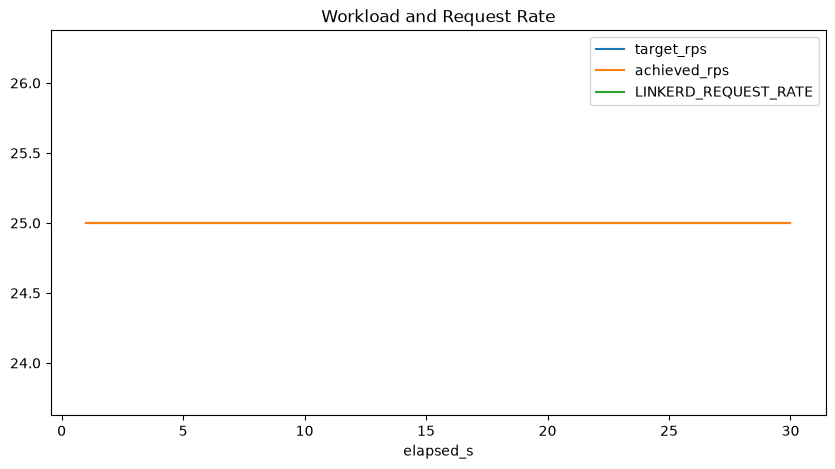

In [5]:
cols=[c for c in ['target_rps','achieved_rps','LINKERD_REQUEST_RATE'] if c in df]
if cols: df.plot(x='elapsed_s',y=cols,figsize=(10,5),title='Workload and Request Rate'); plt.show()


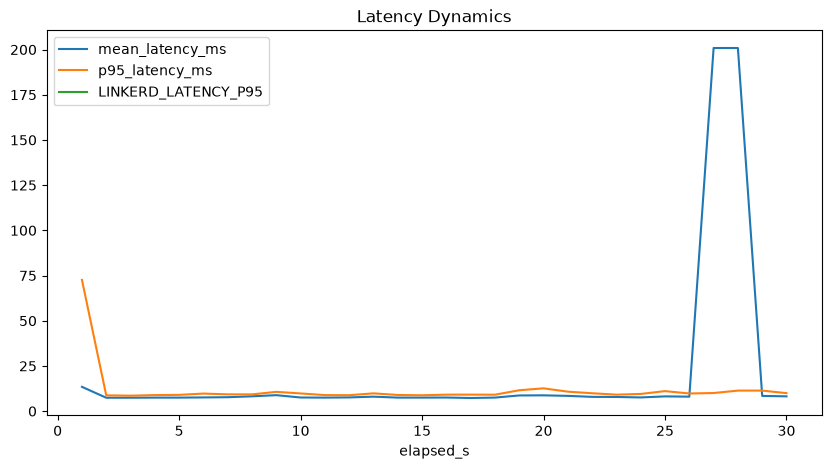

In [6]:
cols=[c for c in ['mean_latency_ms','p95_latency_ms','LINKERD_LATENCY_P95'] if c in df]
if cols: df.plot(x='elapsed_s',y=cols,figsize=(10,5),title='Latency Dynamics'); plt.show()


In [7]:
numeric=df.select_dtypes(include='number'); drivers=[c for c in ['target_rps','achieved_rps'] if c in numeric]
numeric.corr()[drivers] if drivers else pd.DataFrame()


,target_rps,achieved_rps
timestamp_epoch,NaN,NaN
elapsed_s,NaN,NaN
target_rps,NaN,NaN
sent,NaN,NaN
success,NaN,NaN
failed,NaN,NaN
achieved_rps,NaN,NaN
mean_latency_ms,NaN,NaN
p95_latency_ms,NaN,NaN
CPU_USAGE,NaN,NaN


In [8]:
OUT=OUTPUTS/EXPERIMENT.name; OUT.mkdir(parents=True,exist_ok=True)
df.describe().T.to_csv(OUT/'notebook-descriptive-statistics.csv')
print('Saved:',OUT)


Saved: /storage3/home/royyana/Project/cloud2023/kubernetes/research/cloud-dynamics-analysis-venv/outputs/constant-20261006T022000Z-r4
